In [11]:
import pandas as pd

df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


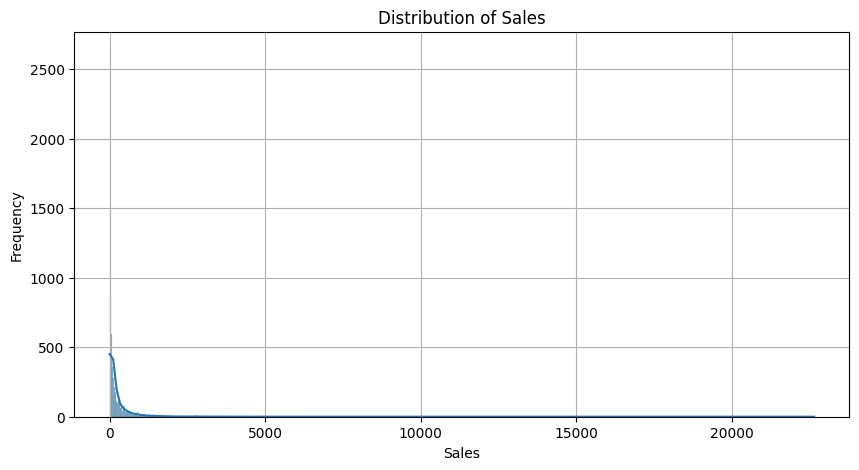

Skewness: 12.97275234181623
Mean: 229.85800083049833
Median: 54.489999999999995


In [12]:
#Task1
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

print("Skewness:", df['Sales'].skew())
print("Mean:", df['Sales'].mean())
print("Median:", df['Sales'].median())

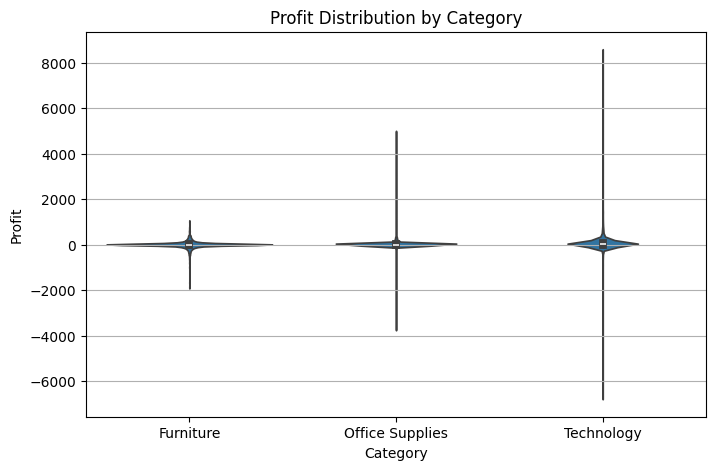

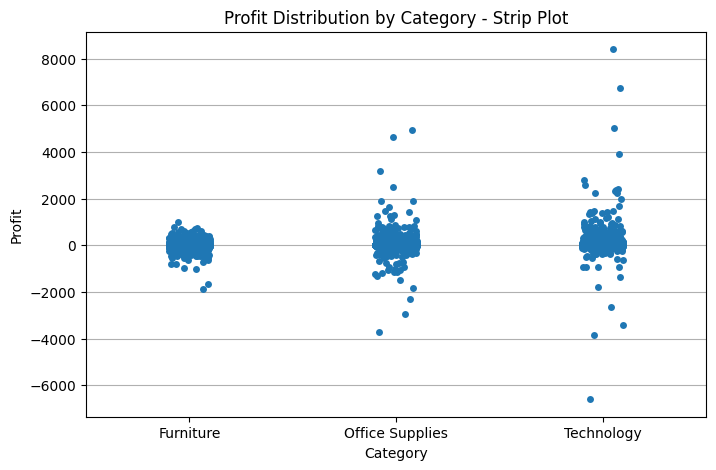

In [13]:
#Task2
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Category', y='Profit')

plt.title('Profit Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()


plt.figure(figsize=(8, 5))
sns.stripplot(data=df, x='Category', y='Profit', jitter=True)
plt.title('Profit Distribution by Category - Strip Plot')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

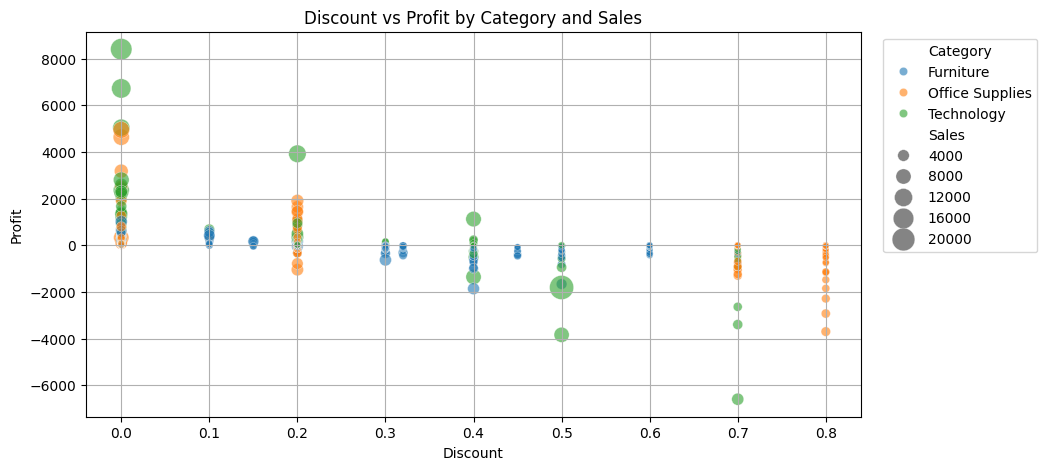

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    size='Sales',
    sizes=(20, 300),
    alpha=0.6
)

plt.title('Discount vs Profit by Category and Sales')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.show()

Pearson Correlation:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


Spearman Correlation:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.011466,-0.001310,-0.002416,0.012655,-0.010545
Postal Code,0.011466,1.000000,-0.002059,0.013952,0.052793,-0.005451
Sales,-0.001310,-0.002059,1.000000,0.327426,-0.056969,0.518407
Quantity,-0.002416,0.013952,0.327426,1.000000,-0.000878,0.234491
Discount,0.012655,0.052793,-0.056969,-0.000878,1.000000,-0.543350
Profit,-0.010545,-0.005451,0.518407,0.234491,-0.543350,1.000000


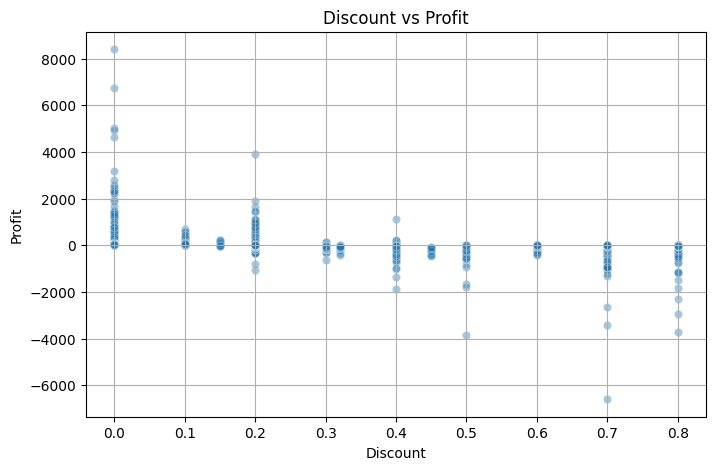

In [18]:
#Task4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=np.number)

pearson_corr = numeric_df.corr(method='pearson')
print("Pearson Correlation:")
display(pearson_corr)

spearman_corr = numeric_df.corr(method='spearman')
print("Spearman Correlation:")
display(spearman_corr)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

Total Sales by Region and Category:


Category,Furniture,Office Supplies,Technology,All
Region,,,,
Central,163797.1638,167026.415,170416.312,5.012399e+05
East,208291.2040,205516.055,264973.981,6.787812e+05
South,117298.6840,125651.313,148771.908,3.917219e+05
West,252612.7435,220853.249,251991.832,7.254578e+05
All,741999.7953,719047.032,836154.033,2.297201e+06


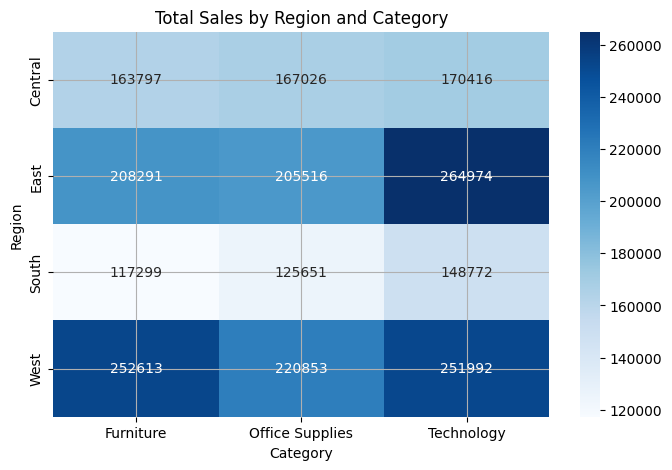

Region-Category with highest sales: ('East', 'Technology')
Total Sales: 264973.981


In [21]:
#Task5
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pivot_table = pd.pivot_table(
    df,
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum',
    margins=True
)

print("Total Sales by Region and Category:")
display(pivot_table)
plt.figure(figsize=(8, 5))

sns.heatmap(
    pivot_table.iloc[:-1, :-1],
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0
)

plt.title('Total Sales by Region and Category')
plt.xlabel('Category')
plt.ylabel('Region')
plt.show()
region_category = pivot_table.iloc[:-1, :-1]
max_pair = region_category.stack().idxmax()
max_value = region_category.stack().max()

print("Region-Category with highest sales:", max_pair)
print("Total Sales:", max_value)

/tmp/ipykernel_9682/1379320741.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df_time['Sales'].resample('M').sum()


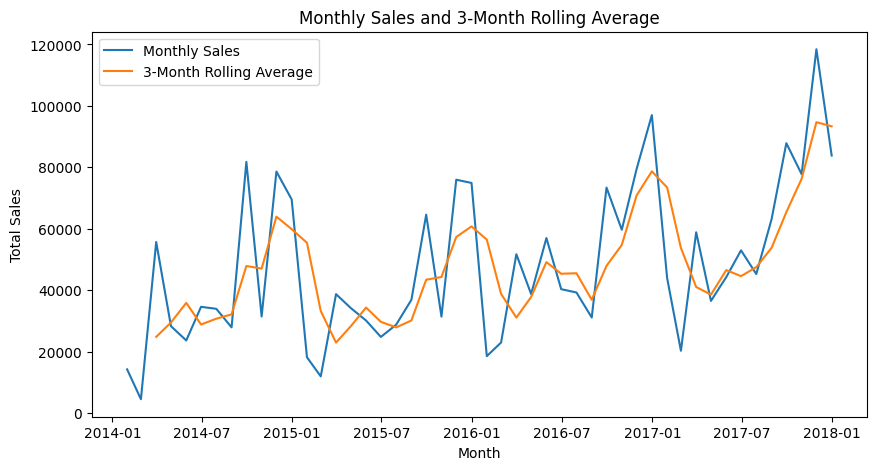

In [22]:
#Task6
import pandas as pd
import matplotlib.pyplot as plt

df['Order Date'] = pd.to_datetime(df['Order Date'])
df_time = df.set_index('Order Date')

monthly_sales = df_time['Sales'].resample('M').sum()
rolling_avg = monthly_sales.rolling(window=3).mean()
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales,
    label='Monthly Sales'
)

plt.plot(
    rolling_avg.index,
    rolling_avg,
    label='3-Month Rolling Average'
)

plt.title('Monthly Sales and 3-Month Rolling Average')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(False)
plt.show()

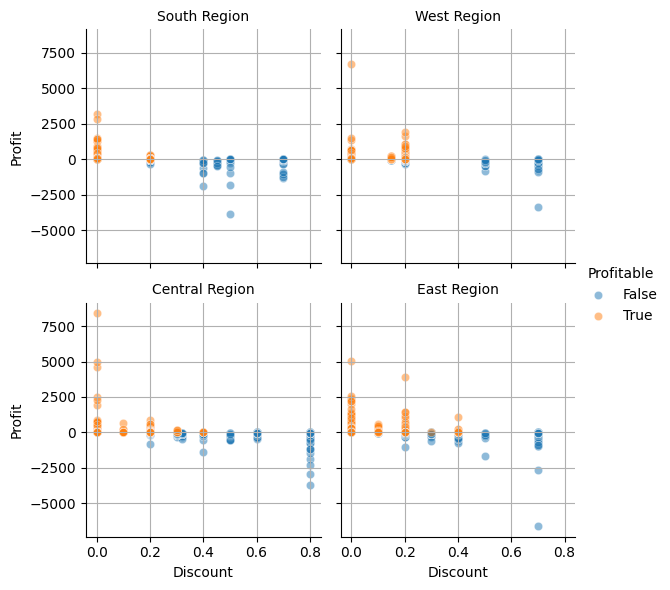

In [23]:
#Task7
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['Profitable'] = df['Profit'] > 0
g = sns.FacetGrid(
    df,
    col='Region',
    hue='Profitable',
    col_wrap=2
)

g.map(
    sns.scatterplot,
    'Discount',
    'Profit',
    alpha=0.5
)

g.add_legend()

g.set_axis_labels('Discount', 'Profit')
g.set_titles('{col_name} Region')

plt.show()

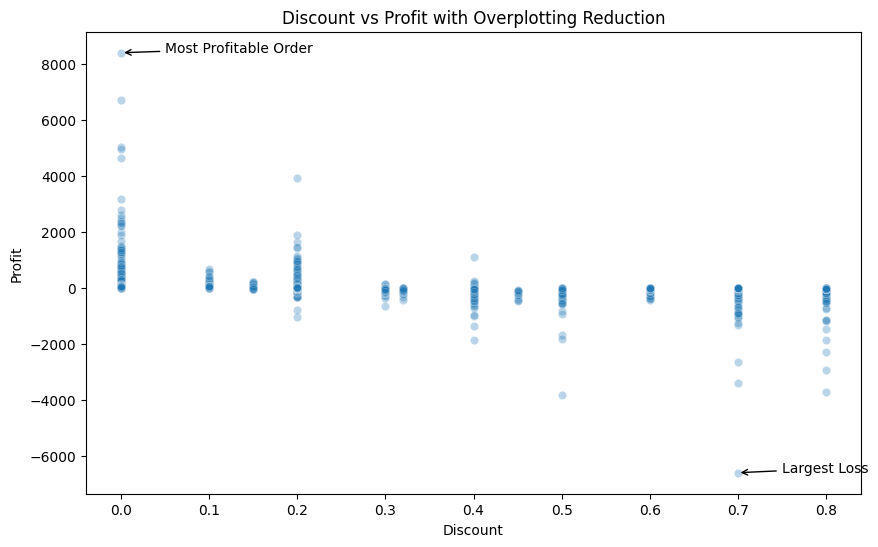

Most profitable order profit: 8399.976
Largest loss: -6599.978


In [24]:
#Task8
import matplotlib.pyplot as plt
import seaborn as sns

max_profit = df.loc[df['Profit'].idxmax()]
max_loss = df.loc[df['Profit'].idxmin()]
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.3
)
plt.annotate(
    'Most Profitable Order',
    xy=(max_profit['Discount'], max_profit['Profit']),
    xytext=(max_profit['Discount'] + 0.05, max_profit['Profit']),
    arrowprops=dict(arrowstyle='->')
)

plt.annotate(
    'Largest Loss',
    xy=(max_loss['Discount'], max_loss['Profit']),
    xytext=(max_loss['Discount'] + 0.05, max_loss['Profit']),
    arrowprops=dict(arrowstyle='->')
)

plt.title('Discount vs Profit with Overplotting Reduction')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(False)
plt.show()

print("Most profitable order profit:", max_profit['Profit'])
print("Largest loss:", max_loss['Profit'])